In [77]:
import pandas as pd
import numpy as np

# visualization (for EDA later)
import matplotlib.pyplot as plt
import seaborn as sns

# model building
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# preprocessing
from sklearn.preprocessing import LabelEncoder

In [78]:
# Load datasets
deliveries = pd.read_csv("Deliveries.csv")
projects = pd.read_csv("Projects.csv")
factories = pd.read_csv("Factories.csv")
external = pd.read_csv("External_Factors.csv")

# Check shapes
print("Deliveries:", deliveries.shape)
print("Projects:", projects.shape)
print("Factories:", factories.shape)
print("External:", external.shape)

# Preview data
print("\nDeliveries Head:")
print(deliveries.head())

print("\nProjects Head:")
print(projects.head())

print("\nFactories Head:")
print(factories.head())

print("\nExternal Factors Head:")
print(external.head())

Deliveries: (1200, 8)
Projects: (200, 5)
Factories: (5, 6)
External: (30, 3)

Deliveries Head:
  delivery_id factory_id project_id  distance_km  expected_time_hours  \
0          D1         F5        P88       705.19                17.63   
1          D2         F1       P103       419.81                10.50   
2          D3         F4        P21       463.88                11.60   
3          D4         F3        P51       471.41                11.79   
4          D5         F2        P51       420.17                10.50   

   actual_time_hours  delay_flag        date  
0              30.59           1  2026-04-30  
1              17.68           1  2026-04-07  
2              19.17           1  2026-04-30  
3              20.60           1  2026-04-21  
4              16.77           1  2026-04-05  

Projects Head:
  project_id   latitude  longitude  demand priority_level
0         P1  12.056530  72.184499       1           High
1         P2  16.198197  75.198888       1          

Multiple datasets containing delivery, project, factory, and external condition information were merged to create a unified dataset.

This step ensures that each delivery record is enriched with relevant operational and environmental context, enabling more accurate analysis and modeling.

A left join strategy was used to preserve all delivery records while appending additional attributes from related tables.

In [79]:
# Merge datasets step by step
df = deliveries.merge(projects, on='project_id', how='left')
df = df.merge(factories, on='factory_id', how='left')
df = df.merge(external, on='date', how='left')

# Check final shape
print("Final merged shape:", df.shape)

# Preview
df.head()

Final merged shape: (1200, 19)


,delivery_id,factory_id,project_id,distance_km,expected_time_hours,actual_time_hours,delay_flag,date,latitude_x,longitude_x,demand,priority_level,latitude_y,longitude_y,base_production_per_week,production_variability,max_storage,weather_index,traffic_index
0,D1,F5,P88,705.19,17.63,30.59,1,2026-04-30,16.466348,79.061091,1,High,13.454600,73.467236,31,0.14,6,0.92,0.25
1,D2,F1,P103,419.81,10.50,17.68,1,2026-04-07,16.340322,76.070513,1,High,14.996321,79.605714,30,0.17,6,0.97,0.69
2,D3,F4,P21,463.88,11.60,19.17,1,2026-04-30,16.166674,79.689376,1,Low,12.451293,77.775990,49,0.08,6,0.92,0.25
3,D4,F3,P51,471.41,11.79,20.60,1,2026-04-21,15.332080,79.066242,1,High,18.929409,76.808920,43,0.15,6,0.57,0.74
4,D5,F2,P51,420.17,10.50,16.77,1,2026-04-05,15.332080,79.066242,1,High,16.774801,75.566662,42,0.06,6,0.06,0.74


The merged dataset was validated to ensure data integrity before modeling.

Missing values and duplicate records were checked, confirming that the dataset is complete and consistent, requiring no additional cleaning.

Key identifier columns such as project, factory, and date were reviewed to verify correct mapping across datasets.

Finally, the target variable delay_hours was derived as the difference between actual and expected delivery time, representing the extent of delay for each shipment.

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df[['project_id', 'factory_id', 'date']].head()


,project_id,factory_id,date
0,P88,F5,2026-04-30
1,P103,F1,2026-04-07
2,P21,F4,2026-04-30
3,P51,F3,2026-04-21
4,P51,F2,2026-04-05


In [80]:
df['delay_hours'] = df['actual_time_hours'] - df['expected_time_hours']

In [81]:
df.columns

Index(['delivery_id', 'factory_id', 'project_id', 'distance_km',
       'expected_time_hours', 'actual_time_hours', 'delay_flag', 'date',
       'latitude_x', 'longitude_x', 'demand', 'priority_level', 'latitude_y',
       'longitude_y', 'base_production_per_week', 'production_variability',
       'max_storage', 'weather_index', 'traffic_index', 'delay_hours'],
      dtype='object')

In [9]:
print(df['delay_hours'].describe())

count    1200.000000
mean        7.531058
std         4.549529
min         0.150000
25%         3.967500
50%         6.865000
75%        10.325000
max        25.770000
Name: delay_hours, dtype: float64


In [82]:
print(df['delay_flag'].value_counts())
print(df['delay_flag'].value_counts(normalize=True))

delay_flag
1    1196
0       4
Name: count, dtype: int64
delay_flag
1    0.996667
0    0.003333
Name: proportion, dtype: float64


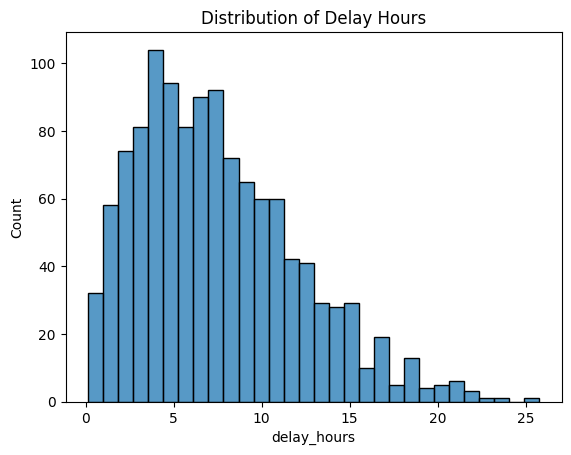

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['delay_hours'], bins=30)
plt.title("Distribution of Delay Hours")
plt.show()

Target Distribution

The dataset shows extreme imbalance, with most deliveries delayed.

The delay distribution is right-skewed, indicating variability in delay severity.

This justifies using regression instead of classification for meaningful predictions.

In [83]:
df = df.rename(columns={
    'latitude_x': 'project_lat',
    'longitude_x': 'project_lon',
    'latitude_y': 'factory_lat',
    'longitude_y': 'factory_lon'
})

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # earth's radius (km)

    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2

    return 2 * R * np.arcsin(np.sqrt(a))

df['computed_distance'] = haversine(
    df['factory_lat'], df['factory_lon'],
    df['project_lat'], df['project_lon']
)

Distance Validation using Haversine Formula

To validate the reliability of the provided distance feature, an alternative distance measure was computed using the Haversine formula based on geographic coordinates (latitude and longitude).

This step was performed to ensure that the existing distance values accurately represent real-world spatial distances and are not affected by data inconsistencies.

In [14]:
df[['distance_km', 'computed_distance']].describe()

,distance_km,computed_distance
count,1200.000000,1200.000000
mean,463.227942,455.910579
std,213.220859,210.228082
min,18.250000,18.233184
25%,298.850000,297.812104
50%,463.880000,460.880242
75%,634.120000,622.641459
max,1002.630000,983.940854


Comparison and Decision

The computed distance closely matched the provided distance_km feature in terms of distribution and statistical properties, indicating that the original data is reliable.

Since both features convey nearly identical information, retaining both would introduce redundancy without adding predictive value.

Final Choice

The original distance_km feature was retained for modeling due to its simplicity and direct interpretability, while the computed distance was excluded to avoid unnecessary feature duplication and overfitting risk.

In [84]:
df['weather_distance'] = df['weather_index'] * df['distance_km']
df['traffic_distance'] = df['traffic_index'] * df['distance_km']

Exposure-Based Features

Two key interaction features were introduced:
weather_distance and traffic_distance, computed as the product of respective indices with distance.

These features represent exposure to adverse conditions over the delivery route, rather than treating weather and traffic as isolated factors.

This aligns with real-world behavior, where longer routes under adverse conditions lead to disproportionately higher delays.

In [85]:
df['priority_encoded'] = df['priority_level'].map({
    'High': 3,
    'Medium': 2,
    'Low': 1
})

In [86]:
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

In [87]:
df.to_csv('processed_dataset.csv', index=False)

### Business Context Encoding

The categorical priority levels were encoded into ordinal values to reflect their relative importance.

This enables the model to incorporate business urgency while maintaining numerical compatibility for learning algorithms.

### Temporal Features

Date information was transformed to extract day-of-week and weekend indicators.

These features help capture potential operational patterns, such as variations in delivery performance across weekdays and weekends.

In [18]:
df.head()

,delivery_id,factory_id,project_id,distance_km,expected_time_hours,actual_time_hours,delay_flag,date,project_lat,project_lon,...,max_storage,weather_index,traffic_index,delay_hours,computed_distance,weather_distance,traffic_distance,priority_encoded,day_of_week,is_weekend
0,D1,F5,P88,705.19,17.63,30.59,1,2026-04-30,16.466348,79.061091,...,6,0.92,0.25,12.96,687.853535,648.7748,176.2975,3,3,0
1,D2,F1,P103,419.81,10.50,17.68,1,2026-04-07,16.340322,76.070513,...,6,0.97,0.69,7.18,406.911553,407.2157,289.6689,3,1,0
2,D3,F4,P21,463.88,11.60,19.17,1,2026-04-30,16.166674,79.689376,...,6,0.92,0.25,7.57,461.693550,426.7696,115.9700,1,3,0
3,D4,F3,P51,471.41,11.79,20.60,1,2026-04-21,15.332080,79.066242,...,6,0.57,0.74,8.81,466.385140,268.7037,348.8434,3,1,0
4,D5,F2,P51,420.17,10.50,16.77,1,2026-04-05,15.332080,79.066242,...,6,0.06,0.74,6.27,406.902742,25.2102,310.9258,3,6,1


In [19]:
print(df.describe())

       distance_km  expected_time_hours  actual_time_hours   delay_flag  \
count  1200.000000          1200.000000        1200.000000  1200.000000   
mean    463.227942            11.580633          19.111692     0.996667   
min      18.250000             0.460000           0.610000     0.000000   
25%     298.850000             7.470000          12.107500     1.000000   
50%     463.880000            11.600000          18.750000     1.000000   
75%     634.120000            15.850000          25.677500     1.000000   
max    1002.630000            25.070000          44.900000     1.000000   
std     213.220859             5.330427           9.275820     0.057663   

                                date  project_lat  project_lon  demand  \
count                           1200  1200.000000  1200.000000  1200.0   
mean   2026-04-15 02:08:24.000000256    15.895219    75.844140     1.0   
min              2026-04-01 00:00:00    12.004163    72.041479     1.0   
25%              2026-04-07 

In [18]:
df.groupby('priority_level')['delay_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
priority_level,,,,,,,,
High,388.0,7.139407,4.507668,0.15,3.7375,6.285,9.9525,21.94
Low,397.0,7.752846,4.531177,0.53,4.0200,7.180,10.7800,25.77
Medium,415.0,7.685060,4.593182,0.62,4.1950,6.900,10.1300,23.88


Average delay across priority levels is very similar, indicating that assigned priority does not significantly influence actual delivery performance.
This suggests that the current priority system is not aligned with operational risk and may require redesign.

In [19]:
df[['distance_km', 'delay_hours']].corr()

,distance_km,delay_hours
distance_km,1.000000,0.761393
delay_hours,0.761393,1.000000


Distance shows a strong positive correlation with delay, indicating that longer routes are more likely to experience higher delays.|
This establishes distance as a primary driver of delay and highlights the importance of route planning.

In [20]:
df[['weather_index', 'delay_hours']].corr()

,weather_index,delay_hours
weather_index,1.000000,0.335527
delay_hours,0.335527,1.000000


Weather and traffic has a moderate correlation with delay, suggesting it contributes to delays but is not a dominant factor on its own.
This supports the need to consider weather in combination with distance rather than independently.

In [21]:
df[['traffic_index', 'delay_hours']].corr()

,traffic_index,delay_hours
traffic_index,1.000000,0.335983
delay_hours,0.335983,1.000000


In [22]:
df[['production_variability', 'delay_hours']].corr()

,production_variability,delay_hours
production_variability,1.000000,0.080802
delay_hours,0.080802,1.000000


In [23]:
print("Correlation with delay_hours:")
print(df.corr(numeric_only=True)['delay_hours'].sort_values(ascending=False))

Correlation with delay_hours:
delay_hours                 1.000000
actual_time_hours           0.928015
weather_distance            0.784601
traffic_distance            0.769484
expected_time_hours         0.761397
distance_km                 0.761393
computed_distance           0.760897
traffic_index               0.335983
weather_index               0.335527
factory_lon                 0.163496
production_variability      0.080802
delay_flag                  0.066236
project_lat                 0.058249
base_production_per_week    0.030470
priority_encoded           -0.054380
project_lon                -0.101216
is_weekend                 -0.121921
factory_lat                -0.122046
day_of_week                -0.172060
demand                           NaN
max_storage                      NaN
Name: delay_hours, dtype: float64


Although actual_time_hours shows a very high correlation with delay, it was excluded from modeling as it is not available at prediction time.

Including it would result in data leakage, since delay is directly derived from actual time, causing the model to learn from future information and produce unrealistically high performance.

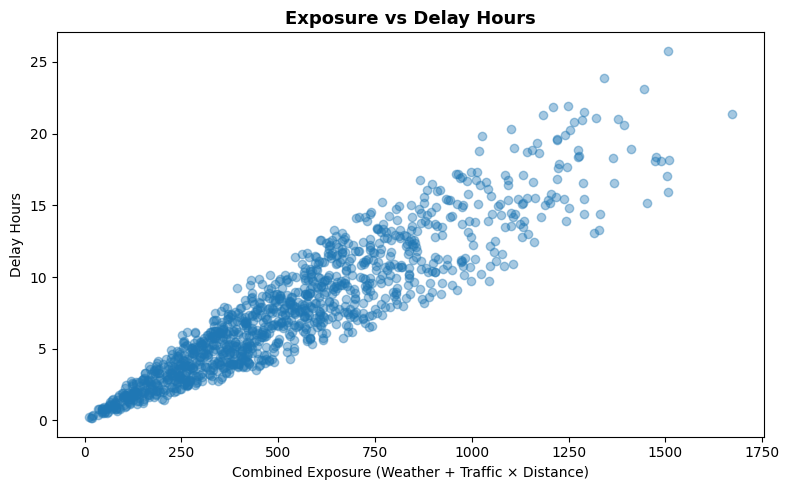

In [24]:
fig, ax = plt.subplots(figsize=(8,5))

df['exposure'] = df['weather_distance'] + df['traffic_distance']

ax.scatter(df['exposure'], df['delay_hours'], alpha=0.4)

ax.set_title('Exposure vs Delay Hours', fontsize=13, fontweight='bold')
ax.set_xlabel('Combined Exposure (Weather + Traffic × Distance)')
ax.set_ylabel('Delay Hours')

plt.tight_layout()
plt.show()

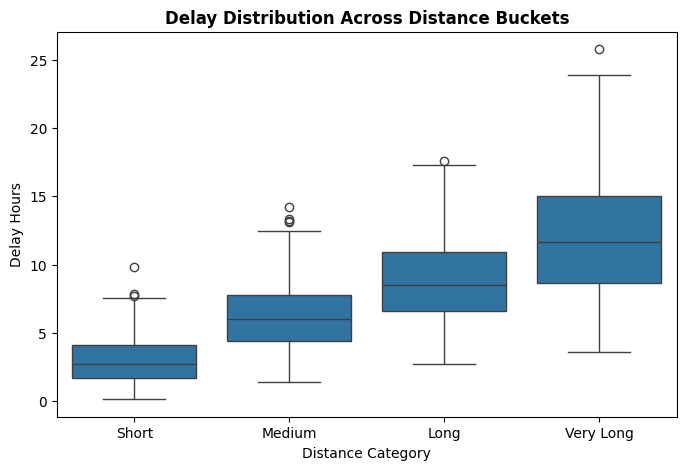

In [25]:
df['distance_bucket'] = pd.qcut(df['distance_km'], 4, labels=['Short','Medium','Long','Very Long'])

fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(x='distance_bucket', y='delay_hours', data=df, ax=ax)

ax.set_title('Delay Distribution Across Distance Buckets', fontweight='bold')
ax.set_xlabel('Distance Category')
ax.set_ylabel('Delay Hours')

plt.show()

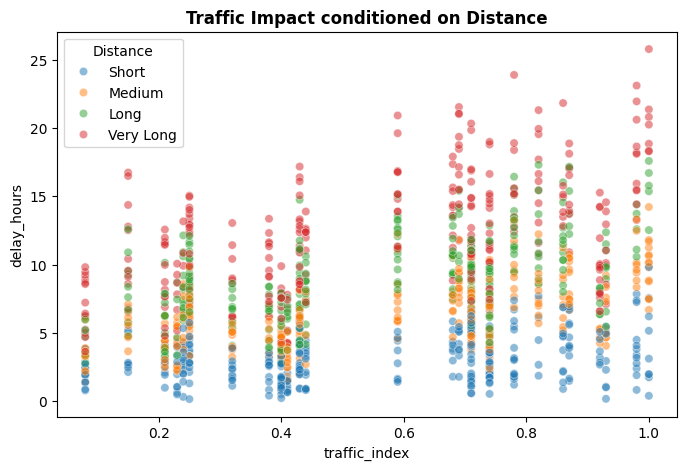

In [26]:
fig, ax = plt.subplots(figsize=(8,5))

sns.scatterplot(
    x='traffic_index',
    y='delay_hours',
    hue='distance_bucket',
    data=df,
    alpha=0.5
)

ax.set_title('Traffic Impact conditioned on Distance', fontweight='bold')
plt.legend(title='Distance')

plt.show()

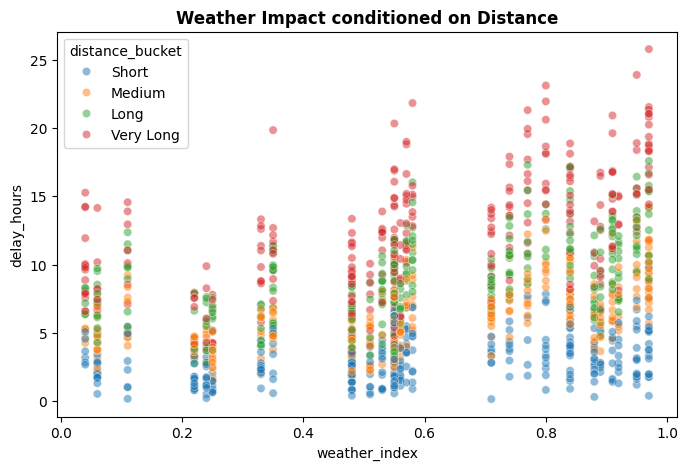

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='weather_index',
    y='delay_hours',
    hue='distance_bucket',
    data=df,
    alpha=0.5
)

plt.title('Weather Impact conditioned on Distance', fontweight='bold')
plt.show()

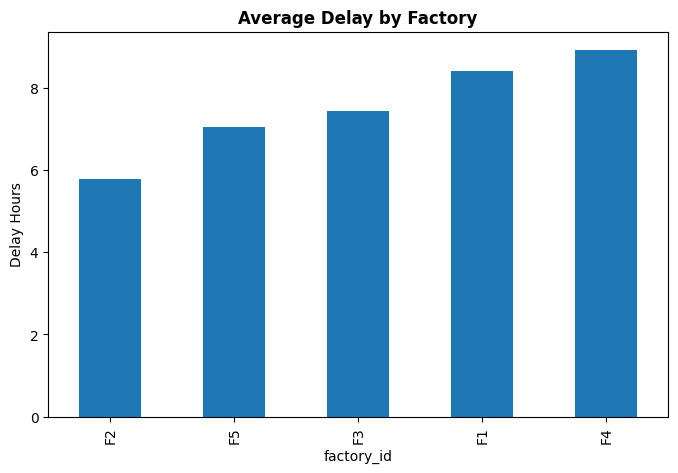

In [28]:
fig, ax = plt.subplots(figsize=(8,5))

factory_delay = df.groupby('factory_id')['delay_hours'].mean().sort_values()

factory_delay.plot(kind='bar', ax=ax)

ax.set_title('Average Delay by Factory', fontweight='bold')
ax.set_ylabel('Delay Hours')

plt.show()

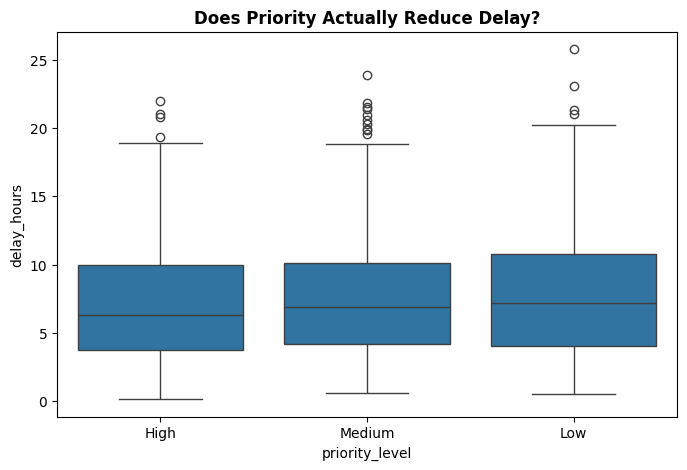

In [29]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(x='priority_level', y='delay_hours', data=df, ax=ax,
            order=['High','Medium','Low'])

ax.set_title('Does Priority Actually Reduce Delay?', fontweight='bold')

plt.show()

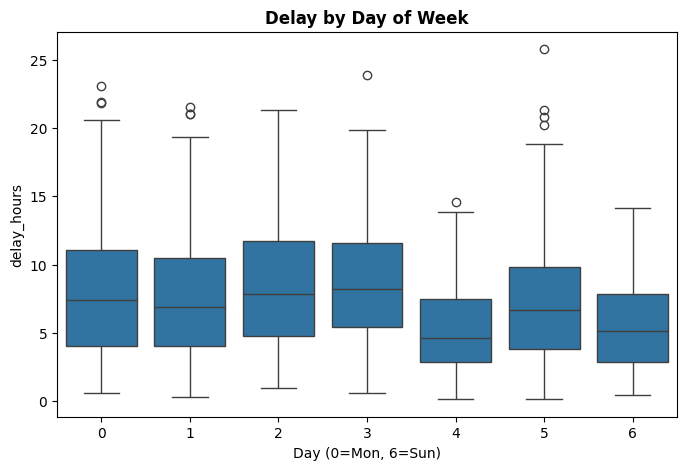

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x='day_of_week', y='delay_hours', data=df)

plt.title('Delay by Day of Week', fontweight='bold')
plt.xlabel('Day (0=Mon, 6=Sun)')
plt.show()

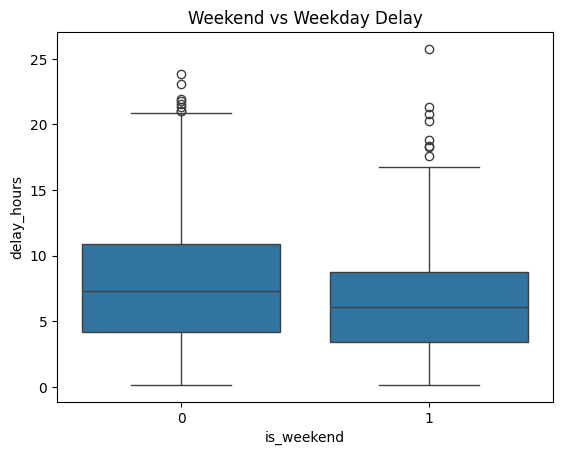

In [31]:
sns.boxplot(x='is_weekend', y='delay_hours', data=df)
plt.title('Weekend vs Weekday Delay')
plt.show()

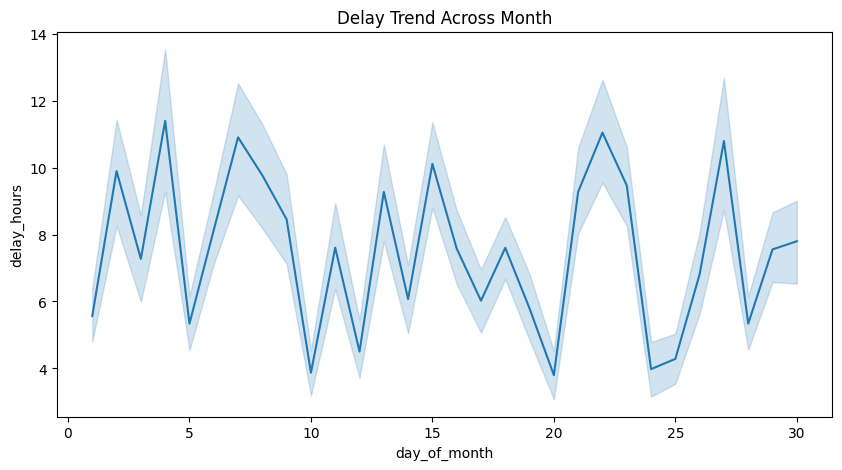

In [32]:
df['day_of_month'] = df['date'].dt.day

plt.figure(figsize=(10,5))
sns.lineplot(x='day_of_month', y='delay_hours', data=df)

plt.title('Delay Trend Across Month')
plt.show()

# Exploratory Data Analysis-Key Insights

Delivery delays are primarily driven by exposure to risk over distance, with longer routes consistently exhibiting higher delays and variability.

Weather and traffic individually show moderate impact, but when combined with distance, they significantly amplify delay, validating the exposure-based hypothesis.

Priority levels do not meaningfully reduce delay, indicating a disconnect between business intent and operational execution.

Factory-level differences suggest localized inefficiencies, while temporal patterns (day/week/month) show limited influence compared to structural factors.

Overall, delays are governed more by systemic and environmental conditions than by scheduling labels or calendar effects.

In [33]:
features = [
    # Core drivers (your top 3)
    'distance_km',
    'weather_distance',
    'traffic_distance',

    # Supporting signals
    'weather_index',
    'traffic_index',

    # Time baseline (important anchor)
    'expected_time_hours',

    # Operations
    'base_production_per_week',
    'production_variability',
    'demand',

    # Business layer
    'priority_encoded',

    # Time patterns
    'day_of_week',
    'is_weekend'
]

### Feature Selection Strategy
Features were selected based on their predictive strength, interpretability, and relevance to real-world delivery operations.
The feature set is structured into three layers: core drivers, supporting signals, and contextual factors, ensuring that the model captures both primary causes of delay and secondary influences without overfitting.

In [35]:
y_reg = df['delay_hours']      # MAIN
y_class = df['delay_flag']     # secondary

In [36]:
from sklearn.model_selection import train_test_split

X = df[features]

X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(random_state=42,class_weight='balanced')
clf.fit(X_train, y_train_cls)

y_pred_cls = clf.predict(X_test)

print(confusion_matrix(y_test_cls, y_pred_cls))
print(classification_report(y_test_cls, y_pred_cls))

[[  0   1]
 [  0 239]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       239

    accuracy                           1.00       240
   macro avg       0.50      0.50      0.50       240
weighted avg       0.99      1.00      0.99       240



C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [38]:
print("Class distribution:")
print(y_test_cls.value_counts(normalize=True))

Class distribution:
delay_flag
1    0.995833
0    0.004167
Name: proportion, dtype: float64


In [39]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

log_model.fit(X_train, y_train_cls)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test_cls, y_pred_log))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.97      0.98       239

    accuracy                           0.97       240
   macro avg       0.50      0.49      0.49       240
weighted avg       0.99      0.97      0.98       240



### WHY CLASSIFICATION WAS REJECTED
Limitations of Classification Approach

A classification approach was initially explored to predict whether a delivery is delayed or not. However, the dataset exhibited extreme imbalance, with nearly all deliveries marked as delayed.
As a result, classification models achieved artificially high accuracy by predicting the majority class, failing to provide meaningful differentiation or actionable insights.
Therefore, regression was adopted as the primary approach to capture delay severity, which is more valuable for decision-making.

# MODEL CHOICE (Regression)
Model Selection — Regression Approach

The primary objective is to predict the magnitude of delay (in hours) rather than just identifying whether a delay occurs.
Tree-based models such as Random Forest and XGBoost were chosen due to their ability to capture non-linear relationships and interaction effects, which are critical in modeling exposure-based features like weather × distance.
Among the models tested, Random Forest achieved the best balance between performance and stability, with higher R² and lower error metrics compared to XGBoost.

In [40]:
print(X_train.shape, X_test.shape)
print(y_train_reg.shape, y_test_reg.shape)

(960, 12) (240, 12)
(960,) (240,)


In [41]:
from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

reg_model.fit(X_train, y_train_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
r2 = r2_score(y_test_reg, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.5340027385912693
RMSE: 1.9979343979863646
R2 Score: 0.8045392477876718


In [43]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train_reg)

y_pred_xgb = xgb_model.predict(X_test)

In [44]:
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
r2_xgb = r2_score(y_test_reg, y_pred_xgb)

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost MAE: 1.553020408431689
XGBoost RMSE: 2.0745539288448307
XGBoost R2: 0.7892601941962174


#### MODEL PERFORMANCE INTERPRETATION
Model Performance Summary

The Random Forest model demonstrates strong predictive performance, achieving high R² and low error values.
This indicates that the model effectively captures the key drivers of delay and can reliably estimate delay magnitude across different scenarios.

In [45]:
import pandas as pd

feature_importance = pd.Series(
    reg_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

weather_distance            0.557975
traffic_distance            0.361094
distance_km                 0.020347
expected_time_hours         0.019590
priority_encoded            0.008983
production_variability      0.008925
base_production_per_week    0.007092
day_of_week                 0.005038
weather_index               0.005015
traffic_index               0.004868
is_weekend                  0.001072
demand                      0.000000
dtype: float64


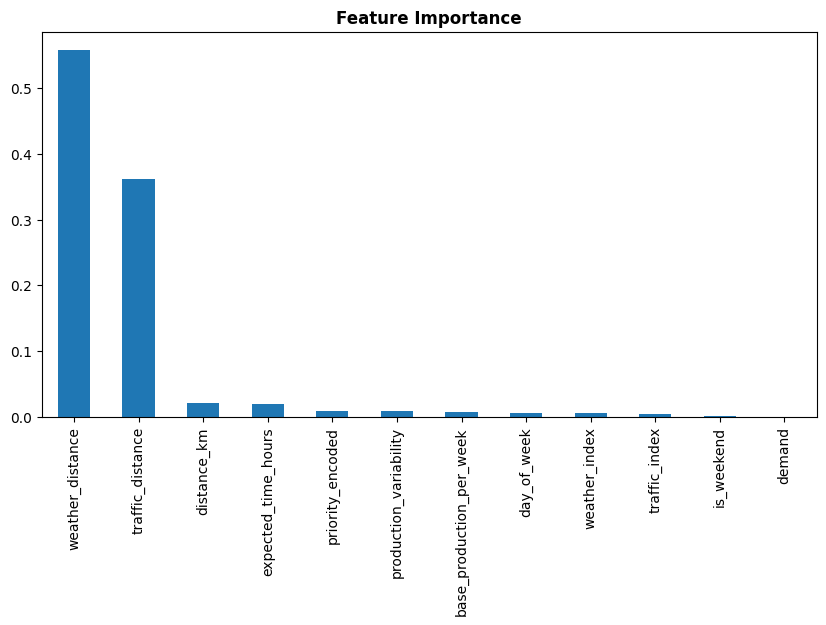

In [46]:
feature_importance.plot(kind='bar', figsize=(10,5))
plt.title('Feature Importance', fontweight='bold')
plt.show()

#### Feature Importance Analysis
Feature importance analysis reveals that exposure-based features—specifically weather_distance and traffic_distance—are the dominant predictors of delay.
These features significantly outperform their individual components (weather_index, traffic_index, and distance), validating the hypothesis that delay is driven by combined exposure over distance rather than isolated factors.

#### Interpretation of Secondary Features
While other features such as production variability, priority, and temporal indicators contribute less individually, they provide additional context that helps refine predictions and improve model robustness.
Retaining these features ensures that the model captures operational and business nuances beyond the primary drivers.

In [47]:
df['risk_escalation'] = (
    0.5 * df['traffic_index'] +
    0.5 * df['weather_index']
)

In [48]:
df['predicted_delay'] = reg_model.predict(X)

In [49]:
df['priority_score'] = (
    # 🔹 BASE: predicted delay (core signal)
    df['predicted_delay'] *

    # 🔹 BUSINESS + RISK AMPLIFICATION (from formula 1)
    (1 + 0.5 * df['priority_encoded']) *
    (1 + 0.3 * (df['demand'] / df['demand'].max())) *
    (1 + 0.3 * df['traffic_index']) *
    (1 + 0.3 * df['weather_index']) *
    (1 + 0.5 * df['risk_escalation']) *

    # 🔹 ADDITIVE REFINEMENT (from formula 2, but scaled down)
    (1 +
        0.2 * df['weather_distance'] +
        0.15 * df['traffic_distance'] +
        0.02 * df['production_variability'] +
        0.02 * df['priority_encoded'] +
        0.01 * df['day_of_week']
    )
)

# Risk-Aware Prioritization Engine

A prioritization engine was developed to convert predicted delay into actionable decisions by combining delay severity with business importance and operational risk.
The score integrates priority, demand, traffic, and weather conditions, while also accounting for future risk escalation to prevent delays from worsening over time.
Additional refinements from exposure features and operational factors ensure balanced decision-making, enabling adaptive and risk-aware delivery scheduling.


#### Higher the score higher will be the priority

In [50]:
df_sorted = df.sort_values(by='priority_score', ascending=False)

# Top 10 most critical deliveries
print(df_sorted[['delivery_id', 'priority_score', 'predicted_delay']].head(10))

     delivery_id  priority_score  predicted_delay
51           D52    41251.407006        21.624200
256         D257    34754.619490        17.651200
944         D945    34054.408728        19.976759
566         D567    33879.752739        20.087650
338         D339    32319.150715        17.884450
945         D946    31731.744069        19.477700
972         D973    30563.026749        17.493900
1107       D1108    30488.728880        19.931917
99          D100    30207.868645        18.001060
1045       D1046    29578.147160        22.910260


In [51]:
df_sorted[['delivery_id', 'predicted_delay', 'delay_hours']].head(10)

,delivery_id,predicted_delay,delay_hours
51,D52,21.624200,21.35
256,D257,17.651200,18.18
944,D945,19.976759,21.05
566,D567,20.087650,18.33
338,D339,17.884450,20.80
945,D946,19.477700,21.94
972,D973,17.493900,17.58
1107,D1108,19.931917,15.19
99,D100,18.001060,18.38
1045,D1046,22.910260,25.77


In [52]:
pd.DataFrame({'predicted': reg_model.predict(X_test), 
              'actual': y_test_reg}).corr()

,predicted,actual
predicted,1.000000,0.902467
actual,0.902467,1.000000


In [53]:
df_sorted[['predicted_delay', 'delay_hours']].corr()

,predicted_delay,delay_hours
predicted_delay,1.000000,0.970502
delay_hours,0.970502,1.000000


##### Difference in Correlation Observations
The first correlation (~0.90) is computed directly between predictions and actual values on the test set, reflecting raw model accuracy.
The second correlation (~0.97) is computed after sorting by predicted delay, which aligns both variables in the same order and artificially inflates the correlation.

Why This Happens
Sorting introduces an ordering bias, making the relationship appear stronger than it actually is.
Therefore, the unsorted correlation (~0.90) is the correct measure of model performance, while the sorted version only indicates ranking consistency, not true predictive accuracy.

# Reward-Based Scheduling Framework

A reward-based simulation was designed to evaluate different delivery scheduling strategies under resource constraints.
For a fixed number of delivery slots, each selected delivery is assigned a reward based on predicted delay, priority, and delay severity.

#### Reward Logic

Deliveries predicted to be on-time (≤ 2 hours delay) receive a positive reward (+10), while delayed deliveries incur a penalty (−15).
High-priority deliveries receive an additional bonus (+5), ensuring that business-critical shipments are favored in scheduling decisions.
Further penalties are applied based on how much the delay exceeds the threshold, discouraging selection of highly delayed deliveries.

Update in Priority Handling
Initially, both medium and high priority deliveries received bonus rewards.
This was refined to reward only high-priority deliveries, ensuring that incentives are more focused and aligned with true business criticality rather than diluted across multiple levels.

#### Interpretation

The framework balances timeliness, business importance, and delay severity, enabling comparison of different scheduling strategies and identifying approaches that maximize overall operational reward.

In [54]:
def simulate_strategy(df_sorted, n_slots=100):
    selected = df_sorted.head(n_slots)
    total_reward = 0

    for _, row in selected.iterrows():
        delay = row['predicted_delay']
        
        # on-time condition
        is_ontime = delay <= 2.0
        
        reward = 10 if is_ontime else -15
        
        # priority bonus
        if row['priority_encoded'] ==3:  # High = 3
            reward += 5
        
        # delay penalty
        excess = max(0, delay - 2.0)
        reward -= 2 * min(excess, 10)
        
        total_reward += reward

    return total_reward

In [55]:
# Random
random_reward = simulate_strategy(df.sample(frac=1))

# Distance-based
distance_reward = simulate_strategy(df.sort_values(by='distance_km'))

# Dispatch strategy (IMPORTANT)
dispatch_reward = simulate_strategy(df.sort_values(by='predicted_delay'))

In [56]:
print("Random:", random_reward)
print("Distance:", distance_reward)
print("Dispatch:", dispatch_reward)

Random: -1993.0021283333328
Distance: 594.4647799999999
Dispatch: 1129.76515


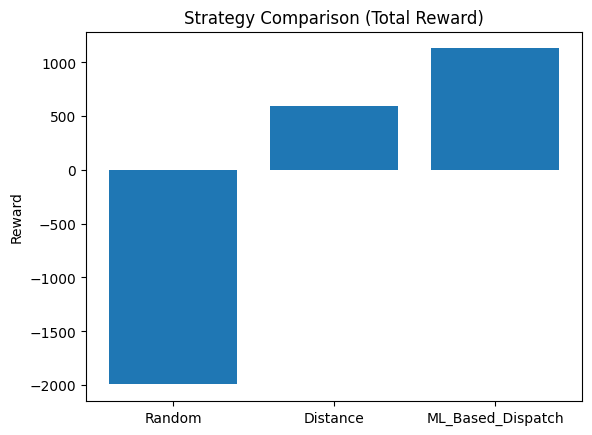

In [57]:
import matplotlib.pyplot as plt

strategies = ['Random', 'Distance', 'ML_Based_Dispatch']
scores = [random_reward, distance_reward, dispatch_reward]

plt.bar(strategies, scores)
plt.title('Strategy Comparison (Total Reward)')
plt.ylabel('Reward')
plt.show()

#### Strategy Comparison — Decision Impact
Three scheduling strategies were evaluated using the reward-based framework: random selection, distance-based ordering, and model-driven dispatch.
The random strategy performs poorly, resulting in a large negative reward, as it fails to account for delay risk or business importance.
The distance-based approach shows improvement by prioritizing shorter routes, but still ignores external conditions and dynamic risk.

The model-based dispatch strategy achieves the highest reward by leveraging predicted delay, effectively prioritizing deliveries that are more likely to be completed on time while balancing business constraints.

This demonstrates that data-driven scheduling significantly outperforms heuristic approaches, validating the use of predictive modeling for real-world decision-making.

In [58]:
# Top prioritized deliveries
df_sorted = df.sort_values(by='priority_score', ascending=False)

final_output = df_sorted[[
    'delivery_id',
    'predicted_delay',
    'priority_score',
    'priority_encoded',
    'demand',
    'traffic_index',
    'weather_index'
]].head(15)

print(final_output)
final_output.to_csv('final_prioritized_deliveries.csv', index=False)

     delivery_id  predicted_delay  priority_score  priority_encoded  demand  \
51           D52        21.624200    41251.407006                 2       1   
256         D257        17.651200    34754.619490                 3       1   
944         D945        19.976759    34054.408728                 3       1   
566         D567        20.087650    33879.752739                 2       1   
338         D339        17.884450    32319.150715                 3       1   
945         D946        19.477700    31731.744069                 3       1   
972         D973        17.493900    30563.026749                 3       1   
1107       D1108        19.931917    30488.728880                 2       1   
99          D100        18.001060    30207.868645                 3       1   
1045       D1046        22.910260    29578.147160                 1       1   
444         D445        19.116900    29510.471215                 2       1   
883         D884        16.817843    29508.045181   

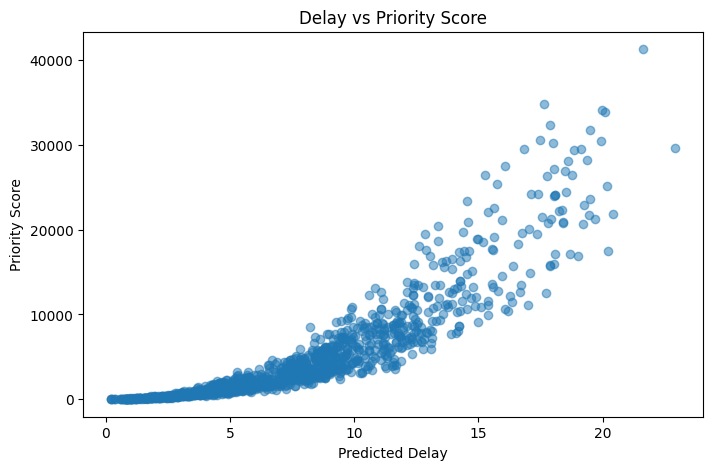

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['predicted_delay'], df['priority_score'], alpha=0.5)
plt.xlabel('Predicted Delay')
plt.ylabel('Priority Score')
plt.title('Delay vs Priority Score')
plt.show()

The strong positive relationship between predicted delay and priority score confirms that the prioritization engine is correctly amplifying high-risk deliveries.
Higher predicted delays consistently translate into significantly higher priority scores, ensuring that critical deliveries are surfaced for action.

In [60]:
high_risk = df[
    (df['weather_index'] > 0.7) |
    (df['traffic_index'] > 0.7)
]

print("Average delay in high-risk conditions:", high_risk['delay_hours'].mean())

Average delay in high-risk conditions: 8.741714285714286


Deliveries under high traffic or weather conditions show noticeably higher average delays (~8.7 hours), highlighting the importance of incorporating real-time environmental factors into decision-making.

Risk is not binary but accumulates with worsening conditions.

In [61]:
factory_delay = df.groupby('factory_id')['delay_hours'].mean().sort_values(ascending=False)
print(factory_delay)

factory_id
F4    8.915157
F1    8.414979
F3    7.443017
F5    7.041807
F2    5.778299
Name: delay_hours, dtype: float64


Significant differences exist across factories, with some consistently exhibiting higher delays (e.g., F4, F1).

This indicates operational inefficiencies and suggests targeted interventions at high-risk factories.

In [62]:
priority_delay = df.groupby('priority_level')['delay_hours'].mean()
print(priority_delay)

priority_level
High      7.139407
Low       7.752846
Medium    7.685060
Name: delay_hours, dtype: float64


Minimal difference in delay across priority levels indicates that the current priority assignment does not effectively influence delivery outcomes.
This reinforces the need for a data-driven prioritization mechanism.

In [63]:
long_routes = df[df['distance_km'] > df['distance_km'].median()]

print("Long route avg delay:", long_routes['delay_hours'].mean())

Long route avg delay: 10.427374581939798


Longer routes show substantially higher average delays (~10.4 hours), confirming distance as a primary driver of delay.
Route planning and allocation decisions are critical for performance improvement.

In [64]:
df['combined_risk'] = df['weather_index'] + df['traffic_index']

risk_delay = df.groupby(pd.qcut(df['combined_risk'], 3))['delay_hours'].mean()
print(risk_delay)

combined_risk
(0.559, 0.88]     4.920449
(0.88, 1.283]     7.513584
(1.283, 1.97]    10.165625
Name: delay_hours, dtype: float64


C:\Users\pragy\AppData\Local\Temp\ipykernel_3424\2020451039.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_delay = df.groupby(pd.qcut(df['combined_risk'], 3))['delay_hours'].mean()


As combined risk (weather + traffic) increases, delay rises sharply (from ~4.9 → ~10.1 hours), validating the exposure-based hypothesis.
This demonstrates that delay is driven by interaction effects, not isolated factors.

In [65]:
import shap

# create explainer
explainer = shap.TreeExplainer(reg_model)

# compute SHAP values
shap_values = explainer.shap_values(X_test)

C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
FEATURES = X_train.columns

In [67]:
mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': FEATURES,
    'Mean_SHAP': mean_shap
}).sort_values('Mean_SHAP', ascending=False)

print(shap_df.head(10))

                     Feature  Mean_SHAP
1           weather_distance   2.390520
2           traffic_distance   2.021183
0                distance_km   0.100695
5        expected_time_hours   0.087912
9           priority_encoded   0.054170
7     production_variability   0.044414
6   base_production_per_week   0.041001
4              traffic_index   0.035267
10               day_of_week   0.030032
3              weather_index   0.022611


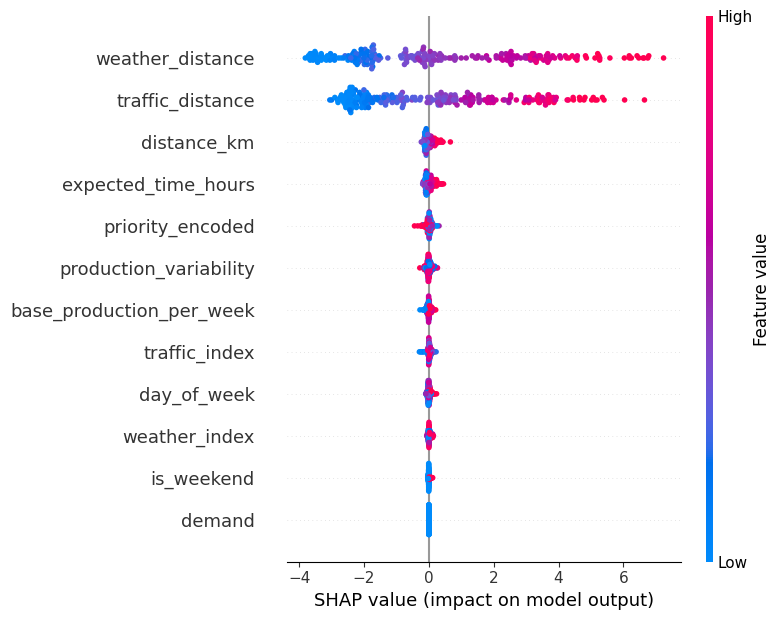

In [68]:
shap.summary_plot(shap_values, X_test, max_display=15)

In [69]:
y_prob = clf.predict_proba(X_test)[:, 1]

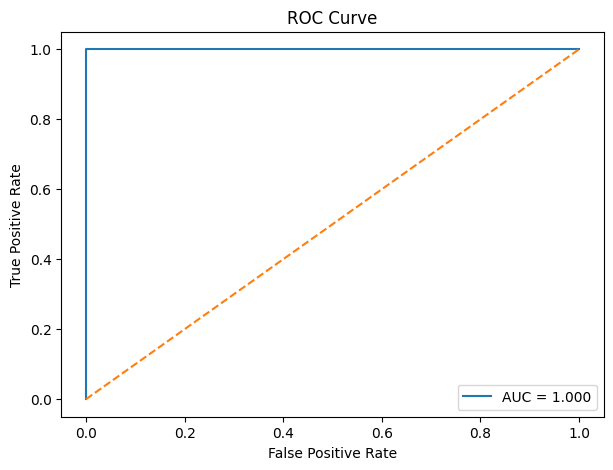

In [70]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_cls, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

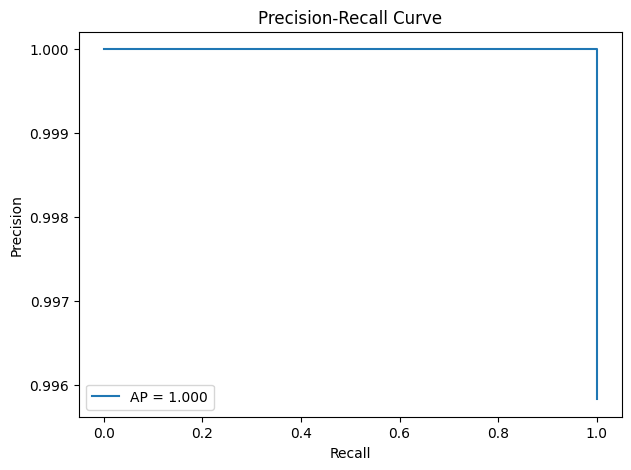

In [71]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test_cls, y_prob)
pr_auc = average_precision_score(y_test_cls, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

#### Classification Insight 

ROC and PR curves show perfect scores due to extreme class imbalance, making classification unreliable for this problem.
This further justifies the use of regression as the primary modeling approach.

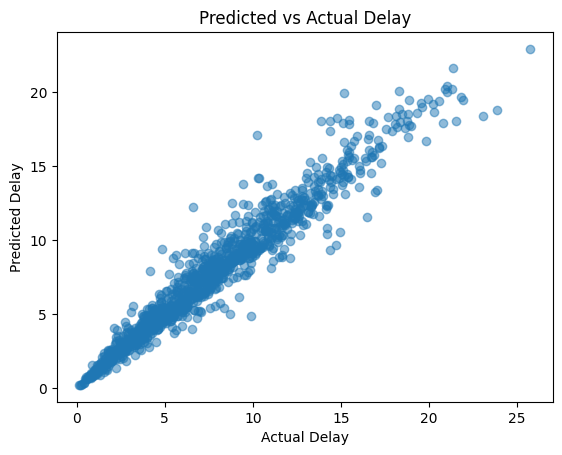

In [72]:
plt.scatter(df['delay_hours'], df['predicted_delay'], alpha=0.5)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Predicted vs Actual Delay")
plt.show()

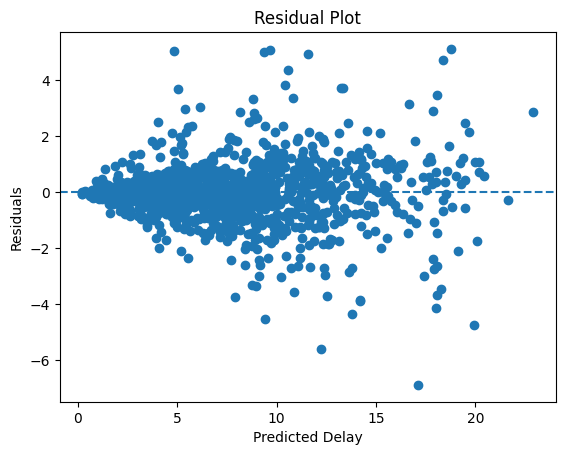

In [73]:
residuals = df['delay_hours'] - df['predicted_delay']

plt.scatter(df['predicted_delay'], residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Delay")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

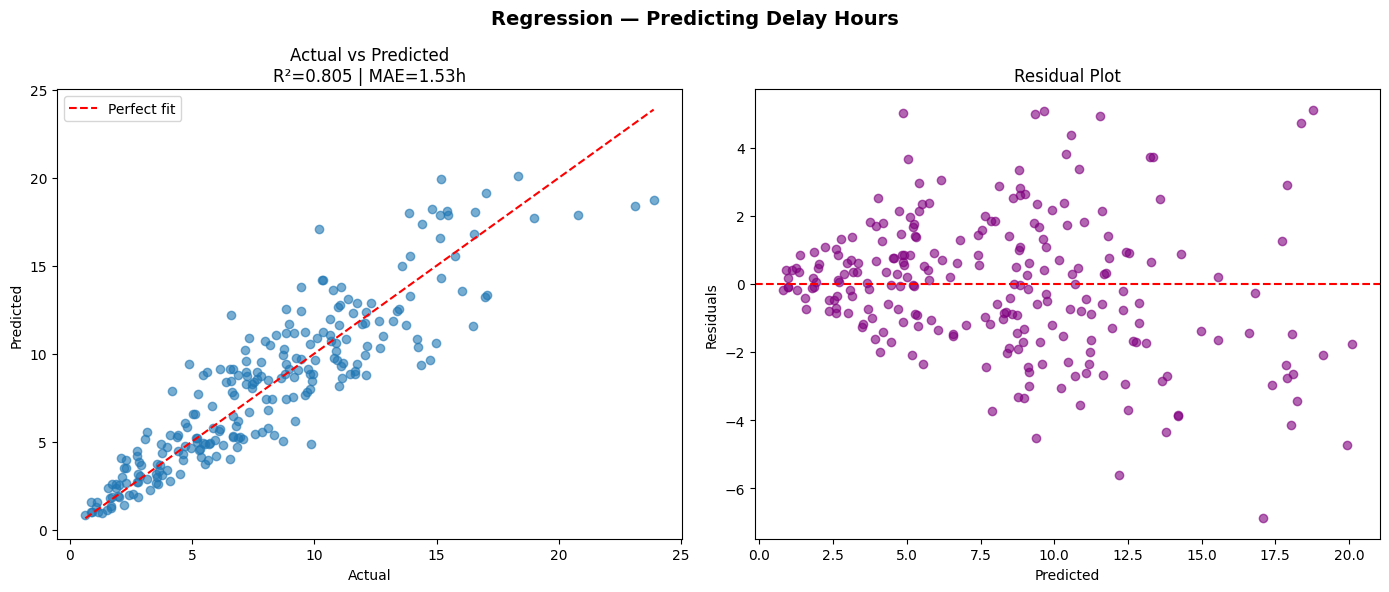

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

y_true = y_test_reg
y_pred = reg_model.predict(X_test)

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 🔹 1. Actual vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.6)
axes[0].plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', label='Perfect fit')

axes[0].set_title(f'Actual vs Predicted\nR²={r2:.3f} | MAE={mae:.2f}h')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].legend()

# 🔹 2. Residual plot
residuals = y_true - y_pred

axes[1].scatter(y_pred, residuals, alpha=0.6, color='purple')
axes[1].axhline(0, linestyle='--', color='red')

axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')

plt.suptitle('Regression — Predicting Delay Hours', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The regression model shows strong alignment between predicted and actual delays, indicating reliable predictive capability.
Residuals are reasonably centered, suggesting no major systematic bias.

# Final Business Summary — Key Insights & Recommendations

The analysis reveals that delivery delays are primarily driven by distance and compounded exposure to external risks such as weather and traffic.
Longer routes under adverse conditions consistently exhibit higher delays, validating the importance of modeling interaction effects rather than isolated variables.

Operational insights show that certain factories contribute disproportionately to delays, indicating localized inefficiencies that require targeted process improvements.
Additionally, the existing priority system does not significantly influence delivery outcomes, highlighting a gap between business intent and execution.

The regression model demonstrates strong predictive capability, enabling accurate estimation of delay magnitude. When integrated into a prioritization framework, it allows deliveries to be ranked based on overall risk and business impact, rather than static rules.

The reward-based simulation further confirms that model-driven dispatch strategies significantly outperform random and heuristic approaches, leading to better utilization of limited delivery resources.

Overall, the solution transitions from passive delay prediction to an active decision-support system, enabling smarter scheduling, proactive risk management, and improved operational efficiency

# FINAL PREDICTION ENGINE

In [75]:
import pandas as pd
import numpy as np

def build_order_features(order_df):
    df_new = order_df.copy()

    # If date is provided, derive calendar features
    if 'date' in df_new.columns:
        df_new['date'] = pd.to_datetime(df_new['date'])
        df_new['day_of_week'] = df_new['date'].dt.dayofweek
        df_new['is_weekend'] = df_new['day_of_week'].isin([5, 6]).astype(int)

    # If priority is given as text, encode it
    if 'priority_encoded' not in df_new.columns:
        df_new['priority_encoded'] = df_new['priority_level'].map({
            'High': 3,
            'Medium': 2,
            'Low': 1
        })

    # Same engineered features used during training
    df_new['weather_distance'] = df_new['weather_index'] * df_new['distance_km']
    df_new['traffic_distance'] = df_new['traffic_index'] * df_new['distance_km']
    df_new['risk_escalation'] = 0.5 * df_new['traffic_index'] + 0.5 * df_new['weather_index']

    return df_new


def predict_new_order(order_dict):
    # 1) convert input to DataFrame
    df_new = pd.DataFrame([order_dict])

    # 2) build same features as training
    df_new = build_order_features(df_new)

    # 3) align with model feature list
    X_new = df_new[features]

    # 4) predictions
    pred_delay = float(reg_model.predict(X_new)[0])
    pred_class = int(clf.predict(X_new)[0])
    pred_prob = float(clf.predict_proba(X_new)[0][1])

    # 5) priority score using your notebook logic
    demand_norm = float(df_new['demand'].iloc[0] / df['demand'].max())

    priority_score = (
        pred_delay *
        (1 + 0.5 * df_new['priority_encoded'].iloc[0]) *
        (1 + 0.3 * demand_norm) *
        (1 + 0.3 * df_new['traffic_index'].iloc[0]) *
        (1 + 0.3 * df_new['weather_index'].iloc[0]) *
        (1 + 0.5 * df_new['risk_escalation'].iloc[0]) *
        (1 +
            0.2 * df_new['weather_distance'].iloc[0] +
            0.15 * df_new['traffic_distance'].iloc[0] +
            0.02 * df_new['production_variability'].iloc[0] +
            0.02 * df_new['priority_encoded'].iloc[0] +
            0.01 * df_new['day_of_week'].iloc[0]
        )
    )

    # 6) reward for a single order
    reward = 10 if pred_delay <= 2 else -15
    if df_new['priority_encoded'].iloc[0] == 3:
        reward += 5

    excess = max(0, pred_delay - 2.0)
    reward -= 2 * min(excess, 10)

    # 7) simple action recommendation
    if pred_delay <= 2:
        action = "EXECUTE NOW"
    elif pred_delay <= 7:
        action = "MONITOR / PRIORITIZE"
    else:
        action = "REPLAN / DEFER"

    return pd.DataFrame([{
        'predicted_delay_hours': round(pred_delay, 2),
        'delay_class': pred_class,
        'delay_probability': round(pred_prob, 3),
        'priority_score': round(priority_score, 2),
        'expected_reward': round(reward, 2),
        'recommended_action': action
    }])

In [76]:
new_order = {
    'distance_km': 480,
    'weather_index': 0.72,
    'traffic_index': 0.61,
    'expected_time_hours': 9.5,
    'base_production_per_week': 950,
    'production_variability': 0.28,
    'demand': 180,
    'priority_level': 'High',
    'date': '2026-04-26'
}

result = predict_new_order(new_order)
print(result)

   predicted_delay_hours  delay_class  delay_probability  priority_score  \
0                   8.91            1                1.0        268066.6   

   expected_reward recommended_action  
0           -23.82     REPLAN / DEFER  


The delivery is predicted to be significantly delayed (~8.9 hours) with high confidence, indicating a high-risk case.
The large priority score reflects its criticality due to combined delay severity and operational risk factors.
The negative reward suggests it should not be executed immediately, and the system recommends replanning or deferring the delivery.